# 🐻‍❄️ 투빅스 정규세션 4주차 1교시 Image Generative AI 코드 과제 🐻‍❄️



## 과제 목적
이번 과제에서는 이미지 생성 모델의 세 가지 큰 축인 **VAE**, **GAN**, **Diffusion**의 핵심 구현을 직접 코드로 뜯어보고, 마지막으로 Hugging Face의 사전학습 Diffusion 모델을 API처럼 불러와 실습해봅니다.
끝에는 직접 자기가 원하는 모델을 선택 후 써보는 경험까지 고안해보며 활용 능력까지 얻을 수 있도록 해봅니다.




## 제출물

1. 빈칸을 모두 채우고 **전부 실행한** 이 노트북 (출력 포함)
2. 기술블로그 '과제 복습' 섹션 — 마지막에 모델 활용한 [hugging face] question 4 부분만




- **VAE (Variational AutoEncoder)**: 입력 데이터를 확률적인 잠재 공간(latent space)으로 압축한 뒤, 그 분포에서 샘플링하여 새로운 데이터를 생성하는 모델
- **GAN (Generative Adversarial Network)**: Generator(위조지폐범)와 Discriminator(경찰)가 서로 경쟁하며 학습하는 모델
- **Diffusion Model**: 이미지에 점진적으로 노이즈를 주입(Forward process)한 뒤, 그 노이즈를 단계적으로 제거(Reverse process)하도록 학습하여 무작위 노이즈로부터 이미지를 생성하는 모델

Part 1~3에서는 세 모델을 MNIST로 직접 구현/학습하며 원리를 비교하고, Part 4에서는 Hugging Face `diffusers` 라이브러리로 실제 학습된 대형 Diffusion 모델을 실습합니다.


### **모듈 임포트 및 디바이스 설정**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


### **데이터셋 준비 (MNIST dataset)**

In [ ]:
batch_size = 128
epochs = 15

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 539kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.07MB/s]


## **Part 1. VAE (Variational AutoEncoder) 모델 정의 및 학습**

* Encoder: 입력 데이터 x를 받아 잠재 공간(Latent Space)의 파라미터를 추출
  * 고차원의 입력데이터를 저차원의 평균과 로그 분산으로 변환
    * 💡 빈칸 채우기 hint) `self.fc1`을 거쳐 특징을 추출한 뒤, 두 개의 서로 다른 선형 레이어를 통해 각각 평균과 로그 분산을 계산

* Latent Space & Reparameterization
  * 잠재 변수 z를 직접 고정된 값으로 뽑는 것이 아니라, encoder가 만든 분포(평균, 로그 분산)에서 샘플링함
  * Reparameterization Trick: backpropagation는 샘플링 연산을 통과할 수 없다는 문제를 해결하기 위해 샘플링 과정을 미분 가능한 형태로 만들기 위한 수식

* Decoder
  * 샘플링된 잠재 변수 z를 다시 원래의 입력 데이터 차원으로 복원


참고 코드: https://github.com/NoviceStone/VAE/blob/master/models.py

In [ ]:
class VAE(nn.Module):

    def __init__(self, input_size=784, hidden_size=400, latent_size=20):
        super(VAE, self).__init__()

        # Encoder: layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc21 = nn.Linear(hidden_size, latent_size)  # 평균(mu)
        self.fc22 = nn.Linear(hidden_size, latent_size)  # 로그 분산(logvar)

        # Decoder: layers
        self.fc3 = nn.Linear(latent_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, input_size)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        mu = self.fc21(h1)   # 🤔 빈칸을 채워주세요 (h1을 받아 평균을 계산하는 레이어)
        logvar = self.fc22(h1)   # 🤔 빈칸을 채워주세요 (h1을 받아 로그 분산을 계산하는 레이어)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std   # 🤔 빈칸을 채워주세요 (Reparameterization Trick 수식)

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


**✍️ 위에서 채운 `encode` / `reparameterize` 코드가 각각 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* **encode** : 입력 데이터를 latent space 확률 분포의 파라미터(mu, logvar)로 매핑한다. 입력 x를 선형 계층(fc1)과 ReLU 활성화 함수에 통과시켜 은닉 특징 h1을 추출합니다. 이후 h1을 두 개의 독립적인 선형 계층(fc21, fc22)에 각각 통과시켜 mu와 logvar를 병렬로 계산하여 반환한다.

* **reparameterize** : 모델이 backpropagation을 통해 학습할 수 있도록 미분 가능한 방식으로 z를 샘플링하는 reparamenterization trick을 수행한다. logvar에 $0.5$를 곱하고 지수 함수(torch.exp)를 취해 표준편차(std, $\sigma$)로 변환한다. 표준 정규 분포 $\mathcal{N}(0, 1)$에서 무작위 노이즈 `eps`($\epsilon$)를 샘플링(torch.randn_like)한 뒤, $z = \mu + \epsilon \times \sigma$ (mu + eps * std) 수식을 계산하여 최종 잠재 벡터를 반환한다.


### **VAE loss (ELBO)**
* Reconstruction Loss: 복원된 이미지(`recon_x`)가 원본 이미지(`x`)와 얼마나 다른지 측정
* KL Divergence: 잠재공간의 분포가 표준 정규분포와 얼마나 다른지 측정


In [ ]:
def elbo_loss(x, recon_x, mu, logvar):

    B = x.size(0)

    x = x.view(-1, 784)

    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum') / B  # 🤔 빈칸을 채워주세요

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / B  # 🤔 빈칸을 채워주세요

    total_loss = BCE + KLD  # 🤔 빈칸을 채워주세요

    return total_loss


**✍️ 위에서 채운 `elbo_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* ELBO 손실값을 계산하여 원본 데이터를 잘 복원하도록 학습하는 동시에 latent space의 확률 분포가 표준 정규분포를 따르도록 유도한다.
* BCE (Reconstruction Loss): 복원된 데이터(recon_x)와 원본 데이터(x) 간의 오차를 Binary Cross Entropy로 계산하여, 디코더가 원본 데이터를 얼마나 잘 복원했는지 측정한다.
* KLD (Regularization Loss): 인코더가 예측한 잠재 분포(mu, logvar)와 표준 정규 분포 $\mathcal{N}(0, 1)$ 간의 차이를 계산하는 KL 발산(Kullback-Leibler Divergence)이다. 수식 $-\frac{1}{2}\sum(1 + \log\sigma^2 - \mu^2 - \sigma^2)$을 코드로 구현했다.
* total_loss: 복원 손실(BCE)과 정규화 손실(KLD)을 더해 최종 손실값을 구하며, 배치 사이즈(B)로 나누어 배치당 평균 손실을 반환한다.


## **🙋 [VAE] Question 1**
VAE의 ELBO Loss에 KL Divergence 항이 포함되는 이유를 설명해주세요.



* VAE의 ELBO Loss에 KL Divergence 항이 포함되는 이유는 인코더가 추정한 잠재 분포 $q_\phi(z\vert{}x)$를 사전 분포 $p(z)$(주로 표준 정규 분포 $\mathcal{N}(0, I)$)에 근사시키기 위한 정규화(Regularization) 역할을 하기 때문이다. 이를 통해 특정 데이터 포인트에만 매핑되는 과적합(Overfitting)을 방지하고, 잠재 공간(Latent space)의 연속성을 확보하여 무작위 샘플링을 통한 새로운 데이터 생성을 가능하게 만든다.


In [ ]:
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(epochs):

    # ========== Train ==========
    vae.train()
    train_loss = 0

    for x, _ in train_loader:

        x = x.to(device)

        recon, mu, logvar = vae(x)

        loss = elbo_loss(x, recon, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_dataset)

    # ========== Validation ==========
    vae.eval()
    val_loss = 0

    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            recon, mu, logvar = vae(x)
            loss = elbo_loss(x, recon, mu, logvar)
            val_loss += loss.item()

    val_loss /= len(val_dataset)

    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch [1/15] Train Loss: 1.3110 | Val Loss: 1.0129
Epoch [2/15] Train Loss: 0.9584 | Val Loss: 0.9172
Epoch [3/15] Train Loss: 0.9012 | Val Loss: 0.8874
Epoch [4/15] Train Loss: 0.8774 | Val Loss: 0.8681
Epoch [5/15] Train Loss: 0.8639 | Val Loss: 0.8580
Epoch [6/15] Train Loss: 0.8542 | Val Loss: 0.8512
Epoch [7/15] Train Loss: 0.8474 | Val Loss: 0.8461
Epoch [8/15] Train Loss: 0.8416 | Val Loss: 0.8417
Epoch [9/15] Train Loss: 0.8377 | Val Loss: 0.8378
Epoch [10/15] Train Loss: 0.8344 | Val Loss: 0.8337
Epoch [11/15] Train Loss: 0.8314 | Val Loss: 0.8341
Epoch [12/15] Train Loss: 0.8288 | Val Loss: 0.8300
Epoch [13/15] Train Loss: 0.8265 | Val Loss: 0.8281
Epoch [14/15] Train Loss: 0.8246 | Val Loss: 0.8273
Epoch [15/15] Train Loss: 0.8226 | Val Loss: 0.8246


**VAE sampling 시각화**

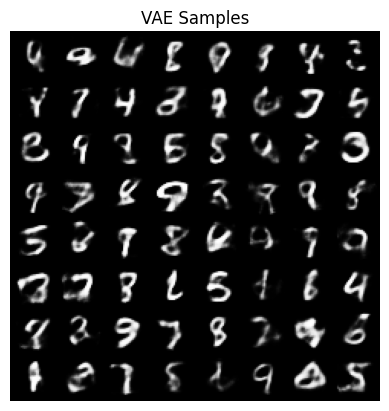

In [ ]:
with torch.no_grad():

    z = torch.randn(64, 20).to(device)

    samples = vae.decode(z).view(-1, 1, 28, 28)

    grid = make_grid(samples, 8)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("VAE Samples")
plt.axis("off")
plt.show()


## **Part 2. DCGAN (Deep Convolutional GAN) 모델 정의 및 학습**
- Weight Initialization
  - 모델의 가중치는 평균이 0, 표준편차가 0.02인 정규분포로 초기화
  - 기존 GAN의 학습 불안정성을 줄이기 위해 DCGAN 논문에서 제안한 아이디어

- Generator (생성자)
  - Transposed Convolution: 저차원의 잠재 벡터를 고해상도 이미지로 확장
  - Batch Normalization: 각 layer의 출력을 정규화하여 학습의 안정성을 높이고 gradient vanishing 문제를 해결
  - Activation: 중간 layer에는 ReLU를 통해 빠른 학습을 진행하고, 마지막 layer에는 이미지의 픽셀 값 범위([-1, 1])를 맞추기 위해 Tanh를 사용

- Discriminator (판별자)
  - Strided Convolution: pooling 대신 stride를 사용하여 특징을 추출
  - 마지막 layer에서 sigmoid를 통해 Real/Fake 확률값 출력


참고 코드: https://github.com/Natsu6767/DCGAN-PyTorch/blob/master/dcgan.py

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)


In [ ]:
# weight 초기화 함수

def weights_init(m):

    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [ ]:
latent_size = 20

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.tconv1 = nn.ConvTranspose2d(latent_size, 256, 7, 1, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(256)

        self.tconv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.tconv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(64)

        self.tconv4 = nn.ConvTranspose2d(64, 1, 3, 1, 1, bias=False)

    def forward(self, z):
        x = F.relu(self.bn1(self.tconv1(z)))   # 🤔 빈칸을 채워주세요 (Generator의 입력)
        x = F.relu(self.bn2(self.tconv2(x)))
        x = F.relu(self.bn3(self.tconv3(x)))
        x = torch.tanh(self.tconv4(x))   # 🤔 빈칸을 채워주세요 (마지막 layer 통과)
        return x


**✍️ 위에서 채운 `Generator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 잠재 벡터(노이즈) z를 입력받아 점진적으로 해상도를 키워 가짜 이미지 데이터를 생성한다.
* 특징 맵 확대: 입력 z를 3개의 전치 합성곱(tconv1, tconv2, tconv3), 배치 정규화(bn1, bn2, bn3), ReLU 활성화 함수에 차례로 통과시켜 채널 수를 줄이고 공간 해상도를 늘린다.
* 최종 출력: 마지막 전치 합성곱(tconv4)을 통과한 후 tanh 활성화 함수를 적용하여 최종 이미지 픽셀 값을 -1과 1 사이로 스케일링하여 반환한다.


In [ ]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=4, stride=2, padding=1, bias=False)

        self.conv2 = nn.Conv2d(64, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256, 1, 3, 1, 0, bias=False)

    def forward(self, x):

        x = F.leaky_relu(self.conv1(x), 0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), 0.2)   # 🤔 빈칸을 채워주세요 (conv3 + bn3 통과)
        x = torch.sigmoid(self.conv4(x))

        return x.view(-1, 1).squeeze(1)


**✍️ 위에서 채운 `Discriminator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 입력된 이미지가 실제 데이터인지 가짜(생성된) 데이터인지 판별하여, 실제 데이터일 확률을 0과 1 사이의 값으로 출력한다.
* 특징 추출 및 다운샘플링: 입력 x를 3개의 합성곱 계층(conv1, conv2, conv3), 배치 정규화(bn2, bn3), 그리고 LeakyReLU(음수 기울기 0.2) 활성화 함수에 차례로 통과시켜 이미지의 특징을 추출하고 해상도를 절반씩 줄여나간다.
* 최종 판별: 마지막 합성곱 계층(conv4)을 거친 후 sigmoid 활성화 함수를 적용하여 값을 확률 형태로 만들고, 출력 차원을 1차원 벡터로 변환(view, squeeze)하여 최종 결과를 반환한다.


In [ ]:
G = Generator().to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCELoss()

optG = optim.Adam(G.parameters(), 0.0002, betas=(0.5, 0.999))
optD = optim.Adam(D.parameters(), 0.0002, betas=(0.5, 0.999))


In [ ]:
for epoch in range(epochs):

    G.train()
    D.train()

    train_lossD = 0
    train_lossG = 0

    for x, _ in train_loader:

        x = x.to(device)

        real = torch.ones(x.size(0)).to(device)
        fake = torch.zeros(x.size(0)).to(device)

        # ========== Train Discriminator ==========

        z = torch.randn(x.size(0), latent_size, 1, 1).to(device)

        fake_img = G(z)

        loss_real = criterion(D(x), real)
        loss_fake = criterion(D(fake_img.detach()), fake)

        lossD = loss_real + loss_fake

        optD.zero_grad()
        lossD.backward()
        optD.step()

        # ========== Train Generator ==========

        loss_G = criterion(D(fake_img), real)  # 🤔 빈칸을 채워주세요 (Generator는 D가 fake_img를 무엇으로 착각하길 원할까요?)

        optG.zero_grad()
        loss_G.backward()
        optG.step()

        train_lossD += lossD.item()
        train_lossG += loss_G.item()

    train_lossD /= len(train_loader)
    train_lossG /= len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}] Loss D: {train_lossD:.4f} | Loss G: {train_lossG:.4f}")


Epoch [1/15] Loss D: 0.7658 | Loss G: 1.7479
Epoch [2/15] Loss D: 0.9224 | Loss G: 1.4445
Epoch [3/15] Loss D: 0.9477 | Loss G: 1.3702
Epoch [4/15] Loss D: 0.9656 | Loss G: 1.3814
Epoch [5/15] Loss D: 0.9625 | Loss G: 1.3927
Epoch [6/15] Loss D: 0.9517 | Loss G: 1.4219
Epoch [7/15] Loss D: 0.9624 | Loss G: 1.4212
Epoch [8/15] Loss D: 0.9328 | Loss G: 1.4620
Epoch [9/15] Loss D: 0.9371 | Loss G: 1.4805
Epoch [10/15] Loss D: 0.9392 | Loss G: 1.4996
Epoch [11/15] Loss D: 0.9128 | Loss G: 1.5311
Epoch [12/15] Loss D: 0.9277 | Loss G: 1.5258
Epoch [13/15] Loss D: 0.8926 | Loss G: 1.5827
Epoch [14/15] Loss D: 0.8876 | Loss G: 1.6064
Epoch [15/15] Loss D: 0.8761 | Loss G: 1.6301


**✍️ 위에서 채운  코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 생성자(Generator)가 판별자(Discriminator)를 속이도록 학습하기 위한 손실값을 계산한다. 생성자는 자신이 만든 가짜 이미지가 진짜로 판별되기를 원하므로, 가짜 이미지에 대한 판별자의 예측값이 1(real)이 되도록 유도한다.
* 판별자 D에 가짜 이미지 fake_img를 통과시킨 출력값과 진짜 데이터를 의미하는 정답 레이블 real(1로 채워진 텐서) 간의 오차를 criterion으로 계산한다.


**DCGAN Sampling 시각화**

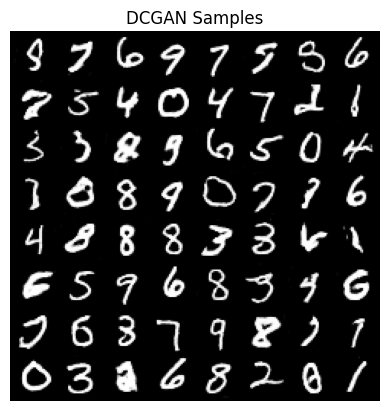

In [ ]:
G.eval()

with torch.no_grad():

    z = torch.randn(64, latent_size, 1, 1).to(device)

    samples = G(z)

grid = make_grid(samples, 8, normalize=True)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("DCGAN Samples")
plt.axis("off")
plt.show()


## **🙋 [GAN] Question 1**
VAE와 DCGAN으로 MNIST 이미지를 생성한 결과 VAE는 흐릿한 이미지, DCGAN은 선명한 이미지가 생성된 것을 알 수 있습니다. 그 이유를 VAE와 GAN의 특징과 학습 방식을 포함하여 설명해주세요.

* VAE는 ELBO의 복원 손실(MSE 또는 BCE)을 최소화하는 방식으로 학습한다. 픽셀 단위의 오차를 평균적으로 줄이려다 보니 여러 가능성의 평균값을 출력하게 되어 흐릿한(Blurry) 이미지가 만들어진다. 반면, DCGAN은 판별자를 완벽하게 속이는 것을 목표로 하는 적대적 학습(Adversarial Learning)을 수행한다. 픽셀의 평균 오차가 아닌 실제 데이터 분포의 뚜렷한 특징과 경계를 모사해야 판별자를 속일 수 있으므로 선명한(Sharp) 이미지가 만들어진다.


## **🙋 [GAN] Question 2**
GAN 학습 과정에서 Generator와 Discriminator 중 한쪽이 너무 빨리 강해지면 어떤 문제가 발생할 수 있는지, Mode collapse 또는 Vanishing gradient 개념을 활용하여 설명해주세요.

* 판별자(Discriminator)가 너무 빨리 강해지면 가짜 이미지를 완벽하게 구별하게 되어, 생성자(Generator)를 업데이트할 유의미한 오차 신호가 사라지는 기울기 소실(Vanishing gradient) 문제가 발생한다. 반대로 생성자가 판별자를 쉽게 속이는 특정 이미지 패턴을 발견하면, 데이터의 다양성을 잃고 해당 패턴의 이미지만 반복해서 출력하는 모드 붕괴(Mode collapse) 문제가 발생한다.


## **Part 3. Diffusion Model (DDPM) 원리 구현**

- **Forward process**: 원본 이미지 $x_0$에 $t$번에 걸쳐 점진적으로 Gaussian noise를 주입하여 $x_t$를 만드는 과정. Closed-form으로 한 번에 임의의 t 시점 노이즈 이미지를 계산할 수 있음
  $$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1-\bar{\alpha}_t}\, \epsilon,\quad \epsilon \sim \mathcal{N}(0, I)$$

- **Reverse process**: 노이즈 $x_t$로부터 노이즈 $\epsilon$을 예측하는 신경망(주로 U-Net)을 학습시켜, $x_T$(순수 노이즈)부터 $x_0$까지 역으로 복원

- **손실함수의 단순화**: DDPM 논문의 핵심 기여 중 하나로, 복잡한 분포 비교 대신 신경망이 예측한 노이즈와 실제 주입된 노이즈 사이의 단순 MSE Loss만으로 학습이 가능함
  $$L_{simple} = \mathbb{E}_{t, x_0, \epsilon}\left[\, \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \,\right]$$

이번 파트에서는 **forward process와 손실함수, 노이즈 예측 네트워크의 핵심 구조를 직접 코드로 구현**하며 원리를 이해합니다. 다만 DDPM은 실제로는 대규모 U-Net을 오랜 시간 학습해야 제대로 된 이미지가 나오기 때문에, 짧은 실습 환경(Colab)에서 처음부터 학습시키기엔 한계가 있습니다. 그래서 우리가 구현한 것과 동일한 원리로 학습된 **Hugging Face의 사전학습 MNIST DDPM 모델**을 불러와 실제 reverse process 결과를 확인해봅니다.


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)


### **Noise Schedule 정의**
$\beta_t$를 선형으로 증가시키며, $\alpha_t = 1-\beta_t$, $\bar{\alpha}_t = \prod_{s=1}^{t}\alpha_s$ 를 미리 계산해둡니다.


In [ ]:
T = 1000  # DDPM 논문 기준 총 diffusion step 수

beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)


def forward_diffusion(x0, t):
    """x0(원본 이미지)에 timestep t만큼의 노이즈를 주입해 x_t를 반환"""
    noise = torch.randn_like(x0)

    sqrt_ac = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_omac = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)

    x_t = sqrt_ac * x0 + sqrt_omac * noise   # 🤔 빈칸을 채워주세요 (forward process 수식)

    return x_t, noise


**✍️ 위에서 채운 `forward_diffusion` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 원본 이미지($x_0$)에 특정 시점($t$)에 해당하는 만큼의 가우시안 노이즈를 주입하여, 노이즈가 낀 이미지($x_t$)를 한 번에 계산하고 반환한다.

* torch.randn_like(x0)를 사용하여 원본 이미지와 동일한 형태의 표준 정규 분포 노이즈를 생성한다. 입력된 시점 t에 해당하는 누적 곱 계수($\sqrt{\bar{\alpha}_t}$ 및 $\sqrt{1-\bar{\alpha}_t}$)를 미리 계산된 텐서에서 가져오고, 이미지 차원 연산을 위해 view(-1, 1, 1, 1)로 브로드캐스팅(Broadcasting) 차원을 맞춘다. 재매개변수화 트릭(Reparameterization trick) 수식인 $x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon$을 적용하여 계산된 최종 이미지 x_t와 주입된 noise를 반환한다.


**Forward process 시각화**: t가 커질수록 이미지가 점점 순수 노이즈에 가까워지는 것을 확인해봅시다.

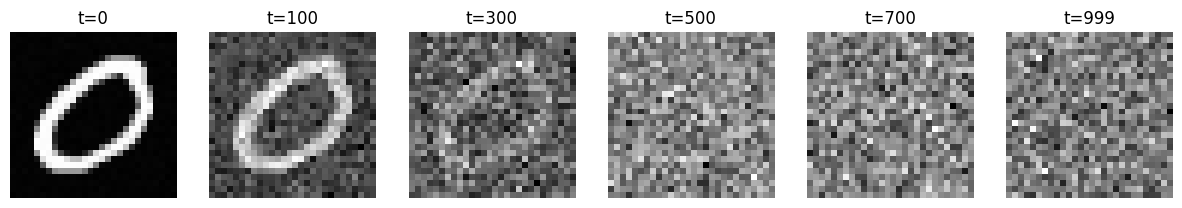

In [ ]:
x0, _ = next(iter(train_loader))
x0 = x0[:1].to(device)

timesteps_to_show = [0, 100, 300, 500, 700, 999]
fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3))

for i, t_val in enumerate(timesteps_to_show):
    t = torch.tensor([t_val]).to(device)
    x_t, _ = forward_diffusion(x0, t)
    axes[i].imshow(x_t[0, 0].cpu().numpy(), cmap="gray")
    axes[i].set_title(f"t={t_val}")
    axes[i].axis("off")

plt.show()


### **U-Net 기반 노이즈 예측 네트워크**
DDPM은 노이즈가 섞인 이미지 $x_t$와 timestep $t$를 입력받아 주입된 노이즈 $\epsilon$을 예측하는 신경망을 사용합니다. 아래는 skip connection을 포함한 축소된 U-Net 구조입니다. Downsampling에서 저장해둔 feature map을 Upsampling 단계에서 다시 이어붙여(concat), 공간 정보 손실을 줄이는 것이 핵심입니다.


In [ ]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb


class SimpleUNet(nn.Module):

    def __init__(self, time_dim=64):
        super().__init__()

        self.time_mlp = nn.Sequential(
            TimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )

        # Downsampling
        self.down1 = nn.Conv2d(1, 64, 3, padding=1)                    # 28 -> 28
        self.down2 = nn.Conv2d(64, 128, 3, stride=2, padding=1)        # 28 -> 14
        self.down3 = nn.Conv2d(128, 256, 3, stride=2, padding=1)       # 14 -> 7

        self.time_proj = nn.Linear(time_dim, 256)

        # Bottleneck
        self.bottleneck = nn.Conv2d(256, 256, 3, padding=1)            # 7 -> 7

        # Upsampling (skip connection으로 채널이 2배가 됨)
        self.up1 = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)   # 7 -> 14
        self.up_conv1 = nn.Conv2d(128 + 128, 128, 3, padding=1)           # skip(h2) concat

        self.up2 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)    # 14 -> 28
        self.up_conv2 = nn.Conv2d(64 + 64, 64, 3, padding=1)              # skip(h1) concat

        self.out = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        # Downsampling (skip connection용으로 각 단계 출력을 저장)
        h1 = F.relu(self.down1(x))      # (B, 64, 28, 28)
        h2 = F.relu(self.down2(h1))     # (B, 128, 14, 14)
        h3 = F.relu(self.down3(h2))     # (B, 256, 7, 7)

        # timestep embedding을 bottleneck 채널에 더해줌
        t_proj = self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h3 = h3 + t_proj   # 🤔 빈칸을 채워주세요 (h3에 timestep 정보를 더해주려면?)

        h3 = F.relu(self.bottleneck(h3))

        # Upsampling + skip connection (concat)
        u1 = F.relu(self.up1(h3))                      # (B, 128, 14, 14)
        u1 = torch.cat([u1, h2], dim=1)                 # (B, 256, 14, 14)
        u1 = F.relu(self.up_conv1(u1))                  # (B, 128, 14, 14)

        u2 = F.relu(self.up2(u1))                       # (B, 64, 28, 28)
        u2 = torch.cat([u2, h1], dim=1)                  # (B, 128, 28, 28)
        u2 = F.relu(self.up_conv2(u2))                   # (B, 64, 28, 28)

        out = self.out(u2)

        return out


**✍️ 위에서 채운 `SimpleUNet.forward`의 timestep 결합 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* U-Net 모델이 현재 입력된 이미지가 확산 과정(Diffusion process)의 어느 시점(timestep $t$)에 해당하는지 인식할 수 있도록 시간 정보를 주입한다.

* 입력된 시점 $t$를 time_mlp에 통과시켜 임베딩 벡터를 생성하고, time_proj 선형 계층을 통해 채널 수를 Bottleneck 단계의 특징 맵(h3)과 동일한 256으로 맞춘다. 이후 unsqueeze를 두 번 적용하여 공간 차원을 확장(1, 1)한 뒤, 브로드캐스팅을 통해 h3 텐서의 모든 픽셀 위치에 해당 시간 임베딩 값을 더해준다(h3 + t_proj).


### **DDPM Loss**
예측한 노이즈와 실제 주입한 노이즈 사이의 MSE Loss입니다.


In [ ]:
def ddpm_loss(model, x0):
    B = x0.size(0)

    t = torch.randint(0, T, (B,), device=device).long()

    x_t, noise = forward_diffusion(x0, t)

    predicted_noise = model(x_t, t)

    loss = F.mse_loss(predicted_noise, noise)   # 🤔 빈칸을 채워주세요 (실제 노이즈 vs 예측 노이즈)

    return loss


**✍️ 위에서 채운 `ddpm_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 원본 이미지에 무작위로 주입된 실제 노이즈와 모델이 예측한 노이즈 간의 오차를 계산하여 DDPM 모델을 학습시키기 위한 손실값을 반환한다.

* 배치 내 각 이미지에 대해 0에서 $T-1$ 사이의 무작위 시점 t를 샘플링한 후, forward_diffusion 함수를 통해 원본 이미지 x0에 시점 t에 해당하는 실제 noise를 주입하여 노이즈 이미지 x_t를 만든다.

* 모델에 노이즈 이미지 x_t와 시점 t를 입력하여 predicted_noise를 예측하게 한 뒤, 실제 주입된 noise와의 평균 제곱 오차(MSE)를 F.mse_loss로 계산한다.

## **🙋 [Diffusion] Question 1**
DDPM은 왜 원본 이미지 $x_0$를 직접 예측하지 않고, 이미지에 주입된 노이즈 $\epsilon$을 예측하도록 학습할까요?

* 수식적으로 $x_0$ 예측과 $\epsilon$ 예측은 동치이나, 매 스텝(timestep)마다 제거해야 할 미세한 노이즈에만 모델이 집중하도록 만드는 것이 전체 이미지를 한 번에 추론하는 것보다 오차가 적고 학습 안정성이 훨씬 높기 때문이다. 특히 노이즈가 많은 상태(큰 $t$)에서 $x_0$를 직접 예측하려 하면 결과물이 심하게 뭉개지는 현상이 발생한다.


In [ ]:
unet = SimpleUNet().to(device)

# 참고: 위에서 구현한 forward_diffusion / SimpleUNet / ddpm_loss가
# DDPM 학습의 핵심 원리 전부입니다. 다만 실제로 눈에 보이는 숫자 이미지를
# 생성할 수준까지 학습시키려면 훨씬 더 큰 모델과 긴 학습 시간이 필요합니다.
# 아래에서는 동일한 원리로 이미 충분히 학습된 사전학습 모델을 불러와
# reverse process 결과를 직접 확인해봅니다.


### **사전학습된 DDPM으로 Reverse Process 결과 확인**

Hugging Face에는 우리가 위에서 구현한 것과 동일한 원리(forward process, 노이즈 예측 U-Net, MSE loss)로 MNIST를 학습시킨 DDPM 모델이 공개되어 있습니다. `DDPMPipeline`을 불러와 실제 reverse process가 어떻게 노이즈에서 숫자 이미지를 만들어내는지 확인해봅시다.


In [ ]:
!pip install -q diffusers transformers accelerate safetensors

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model_index.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

FrozenDict({'num_train_timesteps': 1000, 'beta_start': 0.0001, 'beta_end': 0.02, 'beta_schedule': 'squaredcos_cap_v2', 'trained_betas': None, 'variance_type': 'fixed_small', 'clip_sample': True, 'prediction_type': 'epsilon', 'thresholding': False, 'dynamic_thresholding_ratio': 0.995, 'clip_sample_range': 1.0, 'sample_max_value': 1.0, 'timestep_spacing': 'leading', 'steps_offset': 0, 'rescale_betas_zero_snr': False, '_class_name': 'DDPMScheduler', '_diffusers_version': '0.27.2'})


  0%|          | 0/200 [00:00<?, ?it/s]

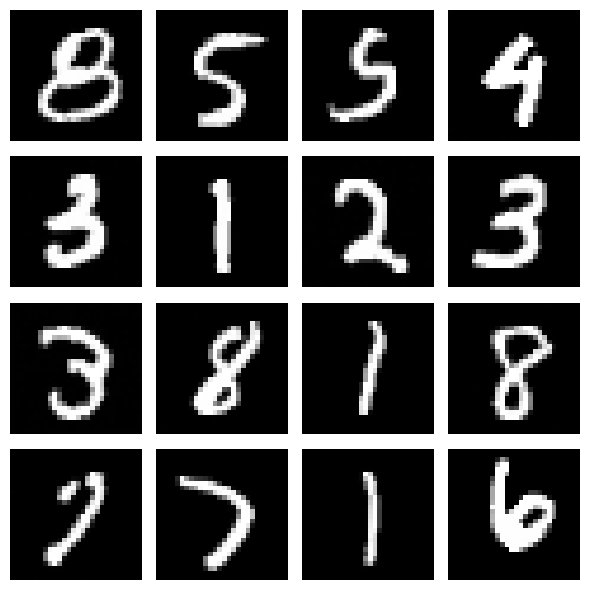

In [ ]:
import torch
import matplotlib.pyplot as plt
from diffusers import DDPMPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = DDPMPipeline.from_pretrained(
    "nathanReitinger/MNIST-diffusion"
).to(device)

# Scheduler 설정 확인
print(pipe.scheduler.config)

# Reverse process
images = pipe(
    batch_size=16,
    num_inference_steps=200
).images

# 결과 확인
fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for ax, image in zip(axes.flatten(), images):
    ax.imshow(image, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 별도 question!
결과가 이상하게 나와서 당황하셨죠?
왜 ddpm은 앞의 vae와 gan과 다르게 일관적이지 않고 어떤건 바르게 어떤 건 완전 악필이 쓴 것처럼 나오는 걸까요?

- 실제 MNIST 데이터셋에 포함된 다양한 형태의 글씨체(악필 포함)와 전체 데이터 분포의 다양성을 DDPM이 누락 없이 그대로 학습하고 재현하기 때문이다.

## **🙋 [Diffusion] Question 2**
VAE, GAN, Diffusion 세 모델을 **학습 안정성**, **생성 품질**, **추론(샘플링) 속도** 세 가지 관점에서 비교해주세요.

앞선 실습 사진을 보고 하는 것이 아닌 이론적으로 비교해주시면 됩니다.아무래도 실습이다보니 이 결과로 비교하는 것은 이론적으로 틀릴 수도 있어서...

**VAE**

* **학습 안정성:** 높음 (안정적)
* **생성 품질:** 낮음 (흐릿함)
* **추론 속도:** 빠름

**GAN**

* **학습 안정성:** 낮음 (불안정함)
* **생성 품질:** 높음 (선명함)
* **추론 속도:** 빠름

**Diffusion**

* **학습 안정성:** 높음 (안정적)
* **생성 품질:** 매우 높음
* **추론 속도:** 느림


## **Part 4. Hugging Face `diffusers`로 사전학습 Diffusion 모델 실습**

Part 3에서 우리는 DDPM의 핵심 원리(forward process, 노이즈 예측 U-Net, MSE loss)를 직접 코드로 구현하고, MNIST 전용 사전학습 모델로 그 결과를 확인해봤습니다. 이번에는 훨씬 크고 복잡한 U-Net을 방대한 이미지-텍스트 데이터로 학습시킨 모델을 다뤄봅니다. 대표적으로 **Stable Diffusion**은 발표자료에서 다룬 것처럼 VAE + Diffusion(Latent Diffusion) + Cross-Attention 기반 Text Conditioning 구조를 가지고 있습니다.

Hugging Face의 `diffusers` 라이브러리를 사용하면 이런 사전학습 모델을 몇 줄의 코드로 불러와 사용할 수 있습니다. Colab에서는 **런타임 유형을 GPU로 설정**한 후 진행해주세요. (런타임 → 런타임 유형 변경 → T4 GPU)


In [ ]:
!pip install -q diffusers transformers accelerate

### **4-1. Text-to-Image: Stable Diffusion**

프롬프트를 입력하면 그에 맞는 이미지를 생성해주는 `StableDiffusionPipeline`을 사용해봅니다. 내부적으로는 텍스트 프롬프트를 CLIP text encoder로 임베딩하고, 이를 조건으로 latent space에서 diffusion(denoising)을 수행한 뒤, VAE decoder로 pixel space 이미지를 복원합니다. (발표자료 33p의 Stable Diffusion 구조 참고)


In [ ]:
import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

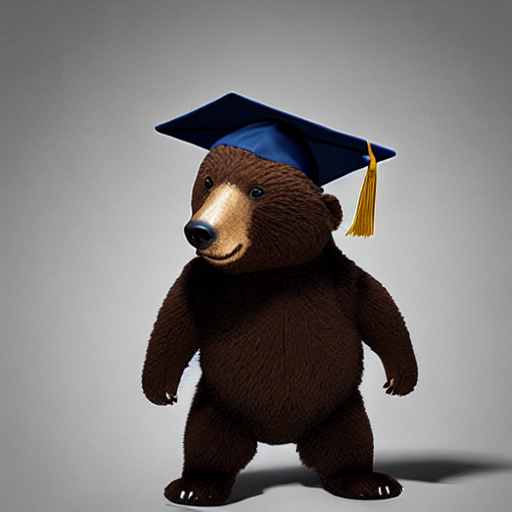

In [ ]:
prompt = "a photo of a bear wearing a graduation cap, studio lighting, high quality"   # 🤔 원하는 프롬프트로 자유롭게 바꿔보세요

image = pipe(
    prompt,
    num_inference_steps=28,   # 🤔 빈칸을 채워주세요 (몇 step 만에 denoising을 마칠지, 예: 25~50)
    guidance_scale=7.5
).images[0]

image


**✍️ 위에서 채운 `num_inference_steps` 코드가 어떤 기능을 하고, 이 값이 커지거나 작아지면 결과가 어떻게 달라지는지 간단히 설명해주세요.**

* 순수한 노이즈 상태에서 최종 이미지를 생성하기까지, 노이즈를 제거하는(Denoising) 과정을 몇 번의 단계(Step)에 나누어 수행할지 결정한다.

* 값이 커질 때는 노이즈를 더 세밀하고 점진적으로 제거하므로 생성된 이미지의 품질과 디테일이 향상되지만, 계산 횟수가 늘어나 연산 시간(추론 속도)이 오래 걸린다.
값이 작아질 때는 적은 단계 만에 빠르게 노이즈를 제거하므로 이미지 생성 속도는 빨라지지만, 생성 과정이 정교하지 못해 이미지의 디테일이 뭉개지거나 전체적인 품질이 저하될 수 있다.


## **🙋 [Hugging Face] Question 1**
위 코드의 `guidance_scale` 파라미터는 발표자료의 **Classifier-free guidance(CFG)** 개념과 관련이 있습니다. `guidance_scale` 값을 낮추거나(예: 1.0) 높이면(예: 15.0) 생성 결과가 각각 어떻게 달라질지 예상해보고, 실제로 두 값으로 각각 이미지를 생성해 비교해주세요.

* 결과를 비교해보면 2.0일 때는 이미지가 자연스럽지만 지시사항이 제대로 반영되지 않았다. 15.0일 때는 조건부의 영향력이 강해져 텍스트 지시를 따르지만, 다양성이 감소하고 색감이 대비되는 것을 볼 수 있다.


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

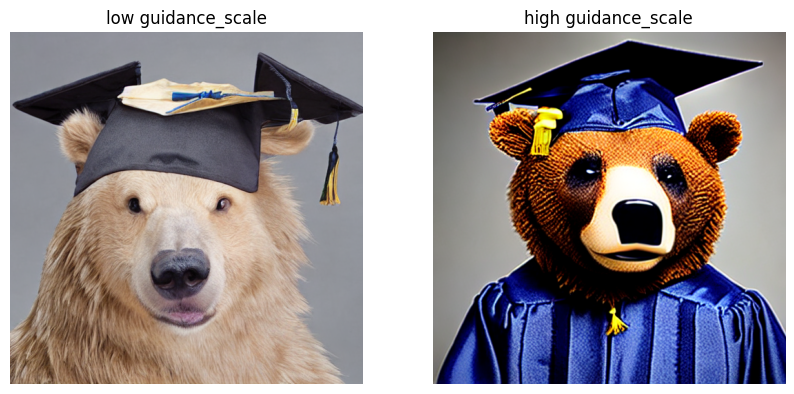

In [ ]:
# 🤔 guidance_scale을 다르게 주어 두 이미지를 생성하고 비교해주세요
prompt = "a photo of a bear wearing a graduation cap, studio lighting, high quality"

image_low_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=2.0).images[0]   # 🤔 빈칸을 채워주세요
image_high_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=15.0).images[0]  # 🤔 빈칸을 채워주세요

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image_low_cfg)
axes[0].set_title("low guidance_scale")
axes[0].axis("off")
axes[1].imshow(image_high_cfg)
axes[1].set_title("high guidance_scale")
axes[1].axis("off")
plt.show()


**✍️ 위에서 채운 `guidance_scale` 비교 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 동일한 텍스트 프롬프트에 대해 guidance_scale 값(2.0과 15.0)만 다르게 설정하여 두 장의 이미지를 생성하고, 프롬프트 반영 강도에 따른 결과물 차이를 시각적으로 비교한다.

* 확산 모델 파이프라인(pipe)에 동일한 프롬프트와 추론 스텝(num_inference_steps=30)을 입력하되, guidance_scale을 각각 2.0과 15.0으로 다르게 주어 image_low_cfg와 image_high_cfg에 저장한다.

* matplotlib.pyplot의 subplots를 이용해 1행 2열의 도화지(fig, axes)를 생성한 뒤, 각각의 축(axes[0], axes[1])에 두 이미지를 나란히 배치하고 제목을 달아 출력(plt.show())한다


### **4-2. Sampler(Scheduler) 교체해보기**

발표자료 33p에서 언급했듯 Stable Diffusion은 하나로 고정된 모델이 아니라, denoising에 사용하는 sampler(scheduler)를 자유롭게 교체할 수 있는 구조입니다. 기본 스케줄러 대신 DDIM 스케줄러로 교체하여 더 적은 step으로도 이미지를 생성해봅니다.


  0%|          | 0/20 [00:00<?, ?it/s]

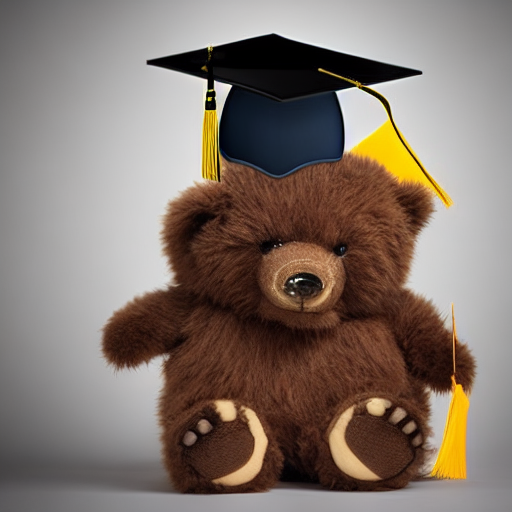

In [ ]:
from diffusers import DDIMScheduler

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

image_ddim = pipe(
    prompt,
    num_inference_steps=20,  # DDPM보다 훨씬 적은 step
    guidance_scale=7.5
).images[0]

image_ddim


## **🙋 [Hugging Face] Question 2**
DDIM 스케줄러가 기본 스케줄러보다 적은 step으로도 그럴듯한 이미지를 생성할 수 있는 이유를 Part 3에서 다룬 DDPM의 reverse process와 비교하여 설명해주세요.

* DDPM의 역방향 과정(Reverse process)은 마르코프 체인(Markov chain)을 기반으로 하므로, $x_t$에서 $x_{t-1}$로 한 단계씩 순차적으로 모든 스텝을 거치며 노이즈를 제거해야 한다. 반면, DDIM은 노이즈 주입 과정의 분산을 0으로 제한하는 비마르코프(Non-Markovian) 과정을 도입하여 무작위성을 없앤 확정적(Deterministic)인 샘플링 방식을 사용한다. 이로 인해 현재 시점 $x_t$에서 예측한 원본 이미지 $x_0$를 바탕으로 중간 과정의 상태를 직접 유추할 수 있어, 모든 스텝을 밟지 않고 듬성듬성 건너뛰며(Skip-step) 훨씬 적은 횟수만으로도 이미지를 생성할 수 있다.


## **🙋 [Hugging Face] Question 3**
직접 해보기 + 허깅 페이스와 인사하기

허깅페이스의 모델 api 활용하기/space에서 모델 3개 이상 활용해보기
둘 중 하나를 택해서 실행하고 간단하게 써본 경험을 공유해주세요!

[예시 노션 링크](https://app.notion.com/p/Hugging-face-3a059e60d52d80f49489f7a3c3ef6648?source=copy_link)

'food_classification_eval_(2).ipynb' 파일에 첨부한 것처럼 제대로 분류된 것과 오분류된 샘플을 확인할 때, 예시 파일 index의 다음 부분을 확인하였다.

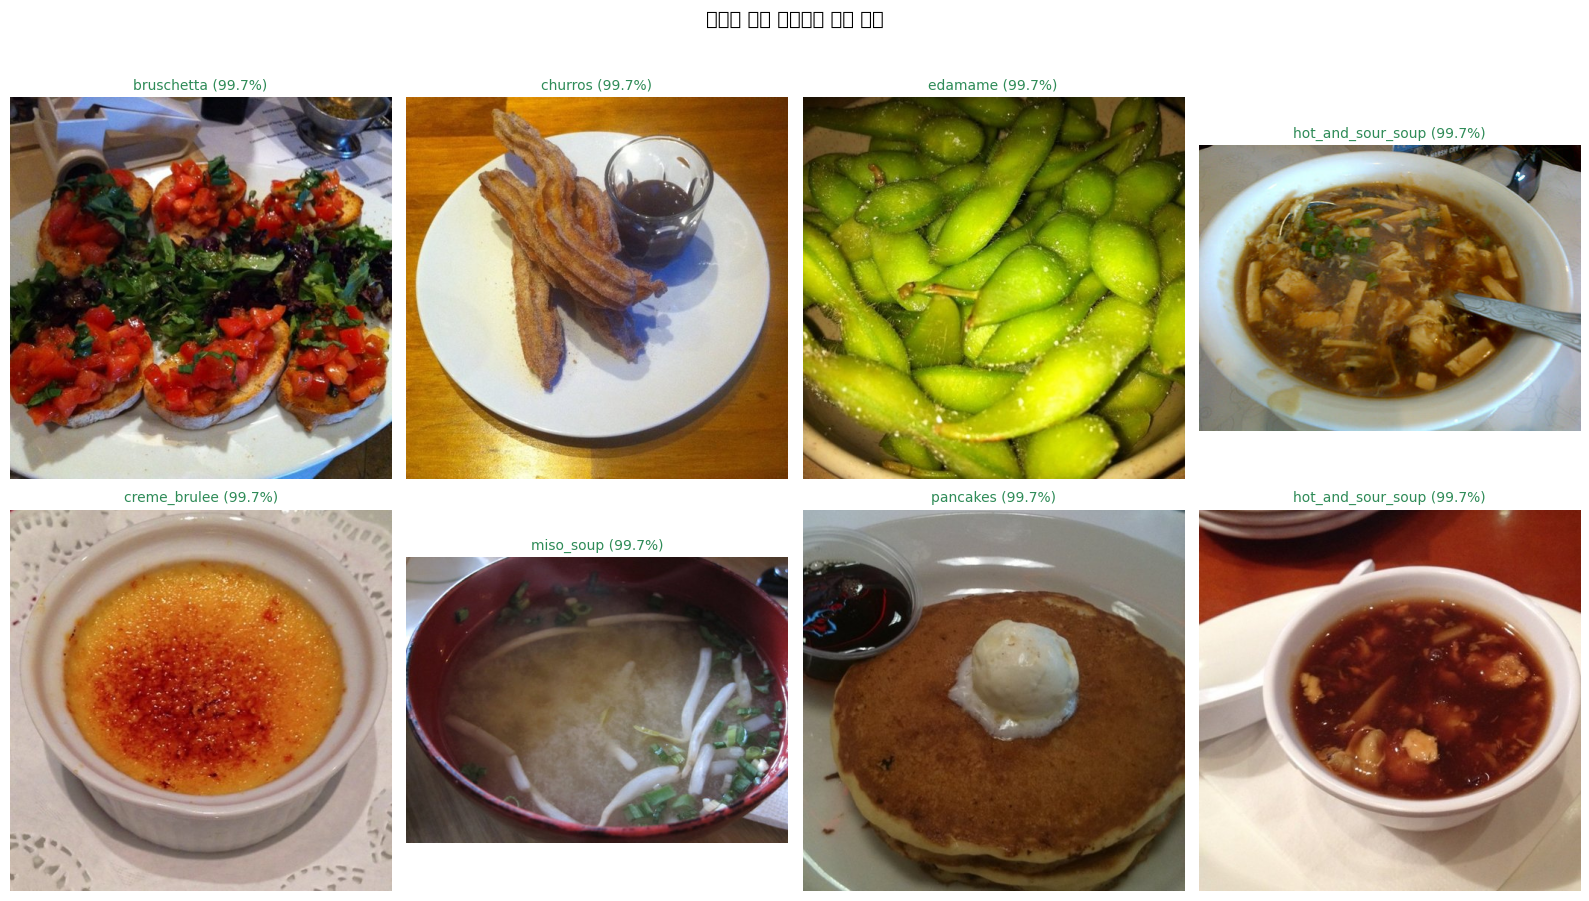


## 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): 학부연구 때 하던 내용과 유사해서 그 부분을 위주로 물어보았다.

- **AI가 이 실험에는 틀린 답을 준 사례** —
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: 없음

- **실제 대화 내역** 붙여넣기:

```
Q. 내가 이전에 학부연구생 때 했던 모델, 코드와 이번 genAI 과제를 비교해줘.

A. ### 1. 모델 아키텍처 및 목적

* **학부 연구:** 데이터의 잠재 공간(Latent Space)을 학습하고 차원 축소를 통해 숨겨진 구조를 파악하는 딥러닝 생성 모델(FactorVAE 등).
* **현재 과제:** 사전 학습된 대형 시각 모델(Vision Transformer, ViT)을 활용해 입력된 이미지의 특징을 추출하고 지정된 101개 클래스 중 하나로 예측하는 판별 및 분류 모델.

### 2. 코드 구현 및 워크플로우

* **학부 연구:** PyTorch를 사용하여 수학적 통계 및 회귀 분석 기반의 모델 구조와 손실 함수를 직접 구현하고, R 등을 활용해 출력 결과를 분석하는 과정 중심.
* **현재 과제:** Hugging Face `transformers` 및 `datasets`의 고수준(High-level) API를 통해 파인튜닝된 모델을 로드하고, `scikit-learn`으로 성능 지표(Top-1/Top-5 Accuracy, F1-score)를 산출하는 추론(Inference) 및 파이프라인 구축 중심.

### 3. 데이터 해석 관점

* **학부 연구:** 모델이 도출한 잠재 변수가 갖는 데이터의 의미를 사회과학적, 통계적 맥락에서 해석하는 데 주력.
* **현재 과제:** 시각적으로 유사한 음식군 간의 오분류 패턴(Confusion Matrix)을 파악하고, 모델의 한계점과 개선 방향을 도출하는 컴퓨터 비전 벤치마크 평가에 주력.

이 중 평가지표 계산 코드나 모델 구조 등 구체적으로 더 깊게 비교해 보고 싶은 부분이 있습니까?
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? 학부 연구를 하면서 경험한 내용은 내가 더 자세히 알고 있기 때문에 나의 자세한 느낌과 AI가 가진 지식을 비교하면서 다양하게 학습할 수 있었다.

수고하셨습니다 ☺️